In [1]:
import os
import cv2
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

from tensorflow.keras.applications import ResNet50
from tensorflow.keras.layers import Conv2D, UpSampling2D
from tensorflow.keras.models import Model

In [2]:
image_folder = "flood_dataset"

files = [f for f in os.listdir(image_folder) if f.endswith((".png",".jpg",".jpeg"))]

print("Dataset files:", files)

Dataset files: ['img4.jpeg', 'img8.jpeg', 'img9.jpeg', 'img5.jpeg', 'img2.jpeg', 'img3.jpeg', 'img1.jpeg', 'img6.jpeg', 'img7.jpeg']


In [3]:
def create_mask(img):

    colors = np.array([
        [0,255,0],      # class 0
        [100,255,100],  # class 1
        [0,255,255],    # class 2
        [0,0,255],      # class 3
        [0,0,139]       # class 4
    ])

    img_flat = img.reshape(-1,3)

    distances = np.linalg.norm(img_flat[:,None] - colors, axis=2)

    mask = np.argmin(distances, axis=1)

    return mask.reshape(img.shape[0], img.shape[1])

In [4]:
images = []
masks = []

for filename in files:

    img_path = os.path.join(image_folder, filename)

    img = cv2.imread(img_path)
    img = cv2.resize(img,(256,256))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = create_mask(img)

    images.append(img)
    masks.append(mask)

images = np.array(images) / 255.0
masks = np.array(masks)

print("Images shape:", images.shape)
print("Masks shape:", masks.shape)

Images shape: (9, 256, 256, 3)
Masks shape: (9, 256, 256)


In [5]:
X_train = images[:8]
y_train = masks[:8]

X_test = images[8:]
y_test = masks[8:]

In [21]:
base_model = ResNet50(
    weights="imagenet",
    include_top=False,
    input_shape=(256,256,3)
)



for layer in base_model.layers:
    layer.trainable = False

In [31]:
x = base_model.output

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(256,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(128,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(64,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)
x = Conv2D(32,(3,3),padding='same',activation='relu')(x)

x = tf.keras.layers.UpSampling2D((2,2))(x)   
x = Conv2D(16,(3,3),padding='same',activation='relu')(x)

outputs = Conv2D(5,(1,1),activation='softmax')(x)

In [23]:
model = Model(inputs=base_model.input, outputs=outputs)

model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 256, 256,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_pad           │ (None, 262, 262,  │          0 │ input_layer_1[0]… │
│ (ZeroPadding2D)     │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_conv (Conv2D) │ (None, 128, 128,  │      9,472 │ conv1_pad[0][0]   │
│                     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_bn            │ (None, 128, 128,  │        256 │ conv1_conv[0][0]  │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv1_relu          │ (None, 128, 128,  │          0 │ conv1_bn[0][0]    │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pad           │ (None, 130, 130,  │          0 │ conv1_relu[0][0]  │
│ (ZeroPadding2D)     │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ pool1_pool          │ (None, 64, 64,    │          0 │ pool1_pad[0][0]   │
│ (MaxPooling2D)      │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_conv │ (None, 64, 64,    │      4,160 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_bn   │ (None, 64, 64,    │        256 │ conv2_block1_1_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_1_relu │ (None, 64, 64,    │          0 │ conv2_block1_1_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_conv │ (None, 64, 64,    │     36,928 │ conv2_block1_1_r… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_bn   │ (None, 64, 64,    │        256 │ conv2_block1_2_c… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_2_relu │ (None, 64, 64,    │          0 │ conv2_block1_2_b… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_conv │ (None, 64, 64,    │     16,640 │ pool1_pool[0][0]  │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_conv │ (None, 64, 64,    │     16,640 │ conv2_block1_2_r… │
│ (Conv2D)            │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_0_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_0_c… │
│ (BatchNormalizatio… │ 256)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2_block1_3_bn   │ (None, 64, 64,    │      1,024 │ conv2_block1_3_c

 Total params: 28,698,565 (109.48 MB)

 Trainable params: 5,110,853 (19.50 MB)

 Non-trainable params: 23,587,712 (89.98 MB)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

In [25]:
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=1
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 4s 100ms/step - accuracy: 0.8200 - loss: 1.0332
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.9453 - loss: 0.3555
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9453 - loss: 0.2841
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 109ms/step - accuracy: 0.9453 - loss: 0.2602
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.9453 - loss: 0.2424
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.2199
Epoch 7/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.2133
Epoch 8/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.2015
Epoch 9/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 95ms/step - accuracy: 0.9453 - loss: 0.1974
Epoch 10/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9453 - loss: 0.1909
Epoch 11/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.9453 - loss: 0.1813
Epoch 12/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.9453 - loss: 0.177

In [26]:
prediction = model.predict(X_test)

pred_mask = np.argmax(prediction, axis=-1)[0]

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 797ms/step


In [27]:
accuracy = np.sum(pred_mask == y_test[0]) / y_test[0].size

print("Pixel Accuracy:", accuracy)

Pixel Accuracy: 0.9731903076171875


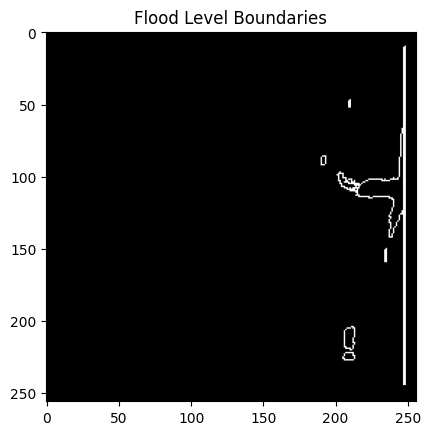

In [28]:
boundary = np.zeros_like(pred_mask)

boundary[:,:-1] |= (pred_mask[:,:-1] != pred_mask[:,1:])
boundary[:-1,:] |= (pred_mask[:-1,:] != pred_mask[1:,:])

boundary = boundary.astype(np.uint8)*255

plt.imshow(boundary,cmap='gray')
plt.title("Flood Level Boundaries")
plt.show()

In [30]:
print("Mask classes:", np.unique(masks))
print("Test mask classes:", np.unique(y_test[0]))
print("Predicted classes:", np.unique(pred_mask))

Mask classes: [0 1 2 3 4]
Test mask classes: [0 1 2 3 4]
Predicted classes: [1 2 3 4]
